In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

In [3]:
insurance = pd.read_csv("C:/Users/Shrinidhi.V/Downloads/insurance.csv")
print(insurance.head())
print(insurance.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)


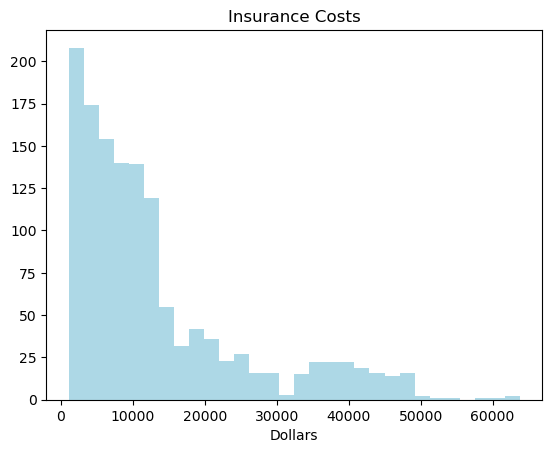

In [5]:
plt.hist(insurance['charges'], bins=30, color='lightblue')
plt.title('Insurance Costs')
plt.xlabel('Dollars')
plt.show()

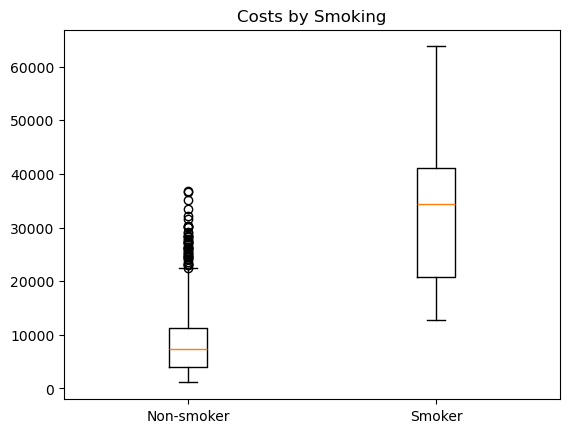

In [6]:
smoker_costs = [insurance[insurance['smoker'] == 'no']['charges'], 
                insurance[insurance['smoker'] == 'yes']['charges']]
plt.boxplot(smoker_costs, labels=['Non-smoker', 'Smoker'])
plt.title('Costs by Smoking')
plt.show()

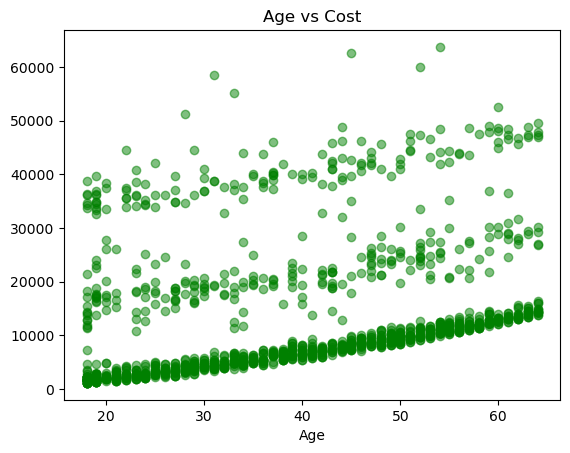

In [8]:
plt.scatter(insurance['age'], insurance['charges'], alpha=0.5, color='green')
plt.title('Age vs Cost')
plt.xlabel('Age')
plt.show()

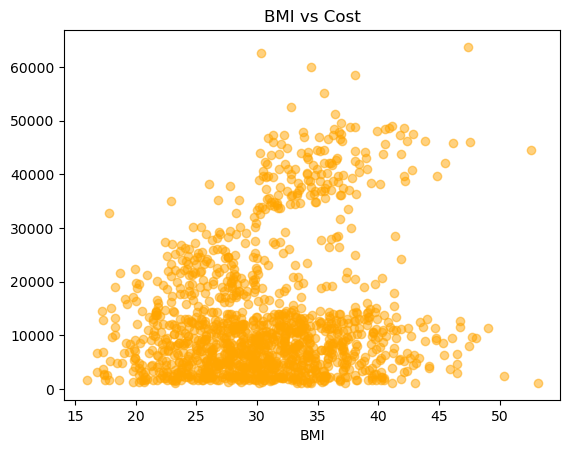

In [10]:
plt.scatter(insurance['bmi'], insurance['charges'], alpha=0.5, color='orange')
plt.title('BMI vs Cost')
plt.xlabel('BMI')
plt.show()

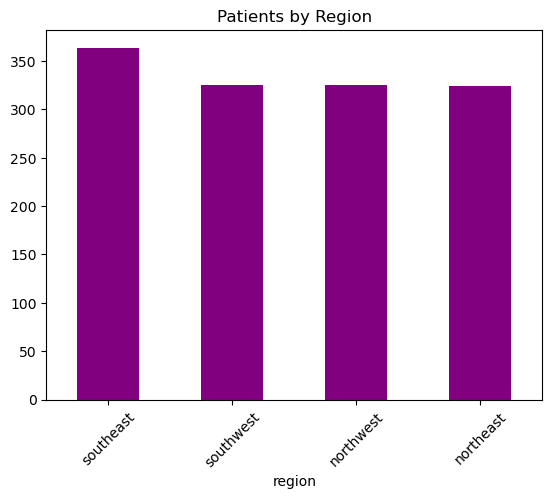

In [12]:
insurance['region'].value_counts().plot(kind='bar', color='purple')
plt.title('Patients by Region')
plt.xticks(rotation=45)
plt.show()

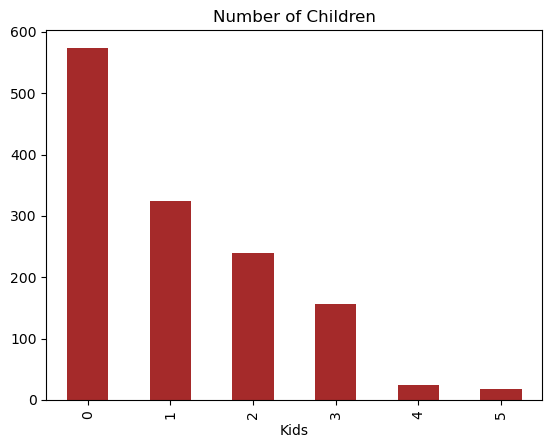

In [14]:
insurance['children'].value_counts().plot(kind='bar', color='brown')
plt.title('Number of Children')
plt.xlabel('Kids')
plt.show()

In [16]:
print(f"Average cost: ${insurance['charges'].mean():.0f}")
print(f"Smokers pay ${insurance[insurance['smoker'] == 'yes']['charges'].mean():.0f} vs ${insurance[insurance['smoker'] == 'no']['charges'].mean():.0f} for non-smokers")

Average cost: $13270
Smokers pay $32050 vs $8434 for non-smokers


In [19]:
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

insurance['sex_encoded'] = le_sex.fit_transform(insurance['sex'])
insurance['smoker_encoded'] = le_smoker.fit_transform(insurance['smoker'])
insurance['region_encoded'] = le_region.fit_transform(insurance['region'])

In [21]:
X = insurance[['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded', 'region_encoded']]
y = insurance['charges']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Average prediction error: ${mae:.0f}")
print(f"Test set average cost: ${y_test.mean():.0f}")
print(f"Error percentage: {(mae/y_test.mean()*100):.1f}%")

Average prediction error: $2536
Test set average cost: $12968
Error percentage: 19.6%


In [29]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nWhat matters most for insurance costs:")
print(feature_importance)


What matters most for insurance costs:
          feature  importance
4  smoker_encoded    0.608618
1             bmi    0.216229
0             age    0.134612
2        children    0.020192
5  region_encoded    0.013938
3     sex_encoded    0.006412


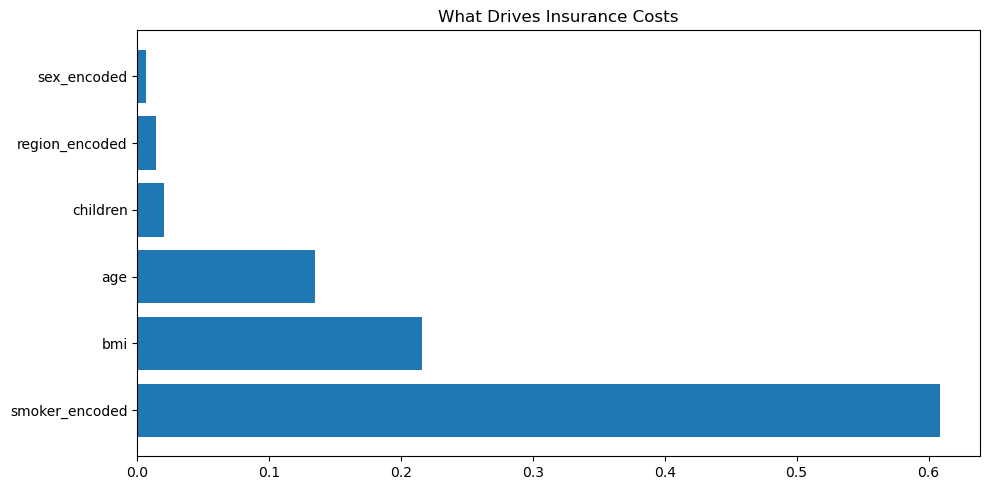

In [31]:
plt.figure(figsize=(10, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('What Drives Insurance Costs')
plt.tight_layout()
plt.show()

In [33]:
sample_person = [[35, 28, 2, 1, 0, 2]]  # 35yo male, BMI 28, 2 kids, non-smoker, southeast
predicted_cost = model.predict(sample_person)[0]
print(f"\nSample prediction: 35-year-old male, 2 kids, non-smoker")
print(f"Predicted insurance cost: ${predicted_cost:.0f}")


Sample prediction: 35-year-old male, 2 kids, non-smoker
Predicted insurance cost: $6254


C:\Users\Shrinidhi.V\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [35]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

In [37]:
insurance['bmi_category'] = pd.cut(insurance['bmi'], 
                           bins=[0, 18.5, 25, 30, 100], 
                           labels=[0, 1, 2, 3])

insurance['age_group'] = pd.cut(insurance['age'], 
                        bins=[18, 30, 40, 50, 60, 70],
                        labels=[0, 1, 2, 3, 4])

insurance['smoker_obese'] = ((insurance['smoker_encoded'] == 1) & (insurance['bmi'] > 30)).astype(int)

In [39]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    error_pct = (mae / y_test.mean()) * 100
    
    print(f"Model: {type(model).__name__}")
    print(f"MAE: ${mae:.0f}")
    print(f"R² Score: {r2:.3f}")
    print(f"Error Percentage: {error_pct:.1f}%")
    print("-" * 40)
    
    return mae, r2
best_model = None
best_score = float('inf')

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    mae, r2 = evaluate_model(model, X_test, y_test)
    
    if mae < best_score:
        best_score = mae
        best_model = model

print(f"Best model: {type(best_model).__name__} with MAE: ${best_score:.0f}")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop Features:")
print(feature_importance.head(10))

Training Random Forest...
Model: RandomForestRegressor
MAE: $2536
R² Score: 0.864
Error Percentage: 19.6%
----------------------------------------
Training Gradient Boosting...
Model: GradientBoostingRegressor
MAE: $2447
R² Score: 0.878
Error Percentage: 18.9%
----------------------------------------
Training XGBoost...
Model: XGBRegressor
MAE: $2790
R² Score: 0.850
Error Percentage: 21.5%
----------------------------------------
Best model: GradientBoostingRegressor with MAE: $2447

Top Features:
          feature  importance
4  smoker_encoded    0.677875
1             bmi    0.190115
0             age    0.117558
2        children    0.010328
5  region_encoded    0.003429
3     sex_encoded    0.000694


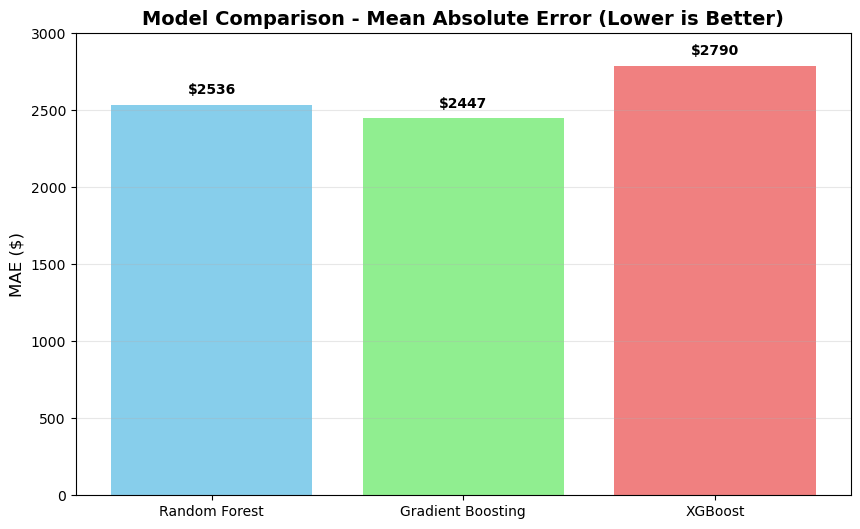

In [40]:
models_comparison = {
    'Random Forest': 2536,
    'Gradient Boosting': 2447,
    'XGBoost': 2790
}

plt.figure(figsize=(10, 6))
bars = plt.bar(models_comparison.keys(), models_comparison.values(), 
               color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Model Comparison - Mean Absolute Error (Lower is Better)', fontsize=14, fontweight='bold')
plt.ylabel('MAE ($)', fontsize=12)
for bar, value in zip(bars, models_comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'${value}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 3000)
plt.grid(axis='y', alpha=0.3)
plt.show()

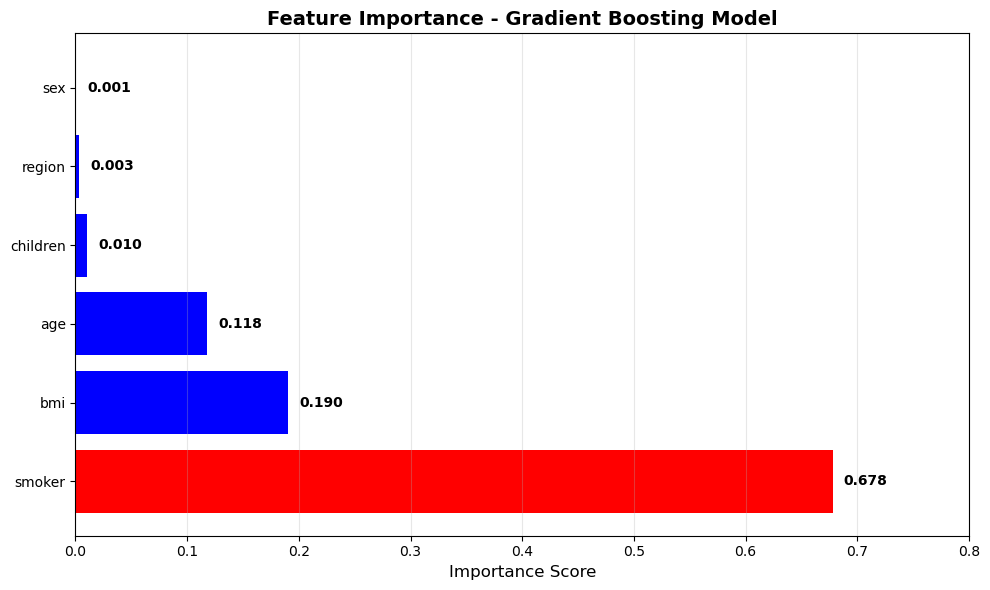

In [43]:
features = ['smoker', 'bmi', 'age', 'children', 'region', 'sex']
importance = [0.677875, 0.190115, 0.117558, 0.010328, 0.003429, 0.000694]

plt.figure(figsize=(10, 6))
colors = ['red' if x == max(importance) else 'blue' for x in importance]
bars = plt.barh(features, importance, color=colors)
plt.title('Feature Importance - Gradient Boosting Model', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)

for bar, value in zip(bars, importance):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', va='center', fontweight='bold')

plt.xlim(0, 0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

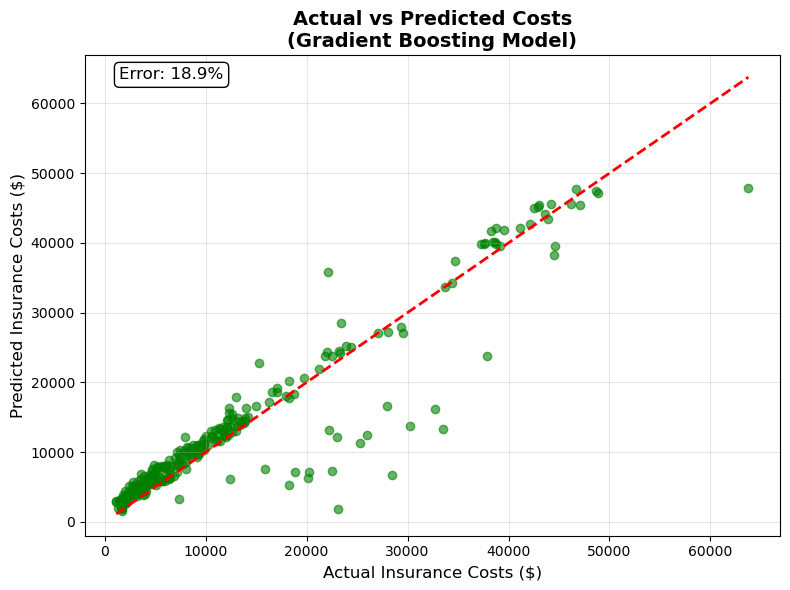

In [45]:
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
predictions = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Insurance Costs ($)', fontsize=12)
plt.ylabel('Predicted Insurance Costs ($)', fontsize=12)
plt.title('Actual vs Predicted Costs\n(Gradient Boosting Model)', fontsize=14, fontweight='bold')
plt.text(0.05, 0.95, f'Error: 18.9%', transform=plt.gca().transAxes, 
         fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white"))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

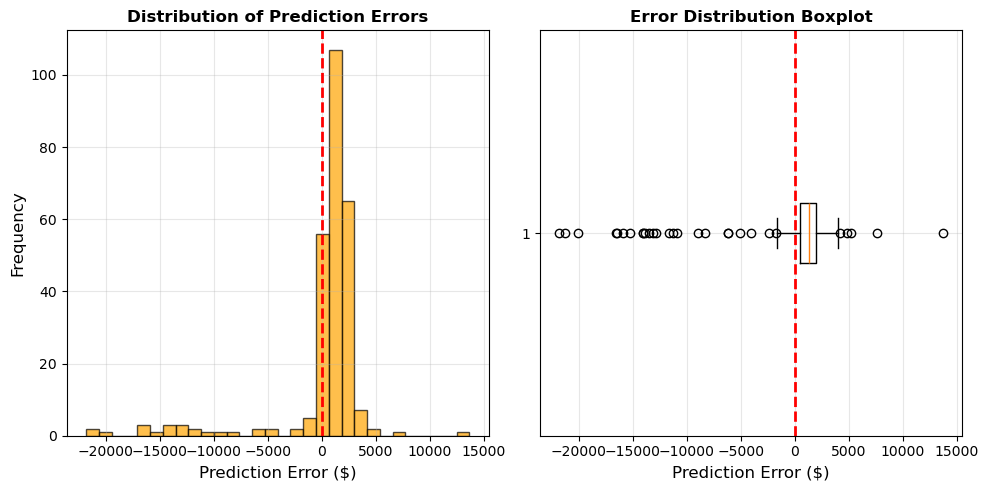

In [47]:
errors = predictions - y_test

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(errors, bins=30, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors', fontweight='bold')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(errors, vert=False)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error ($)', fontsize=12)
plt.title('Error Distribution Boxplot', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
print(f"✅ Best Model: Gradient Boosting")
print(f"✅ Error Reduced from 19.6% to 18.9%")
print(f"✅ Most Important Feature: Smoking (67.8% impact)")

✅ Best Model: Gradient Boosting
✅ Error Reduced from 19.6% to 18.9%
✅ Most Important Feature: Smoking (67.8% impact)
